In [1]:
import os
import pickle
import mlflow
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import scikit_posthocs as sp
import matplotlib.pyplot as plt

from tqdm import tqdm
from numpy import sort
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score
from mlflow.models.signature import infer_signature
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import scale, StandardScaler
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance, XGBRFClassifier
from sklearn.linear_model import LogisticRegression
from scipy.stats import friedmanchisquare
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from aeon.visualisation import plot_critical_difference

In [2]:
files = ['two_class_raw_1s_no.csv', 'two_class_raw_1s_yo_0.5.csv', 'two_class_raw_1s_yo_0.8.csv', 'two_class_raw_2s_no.csv', 'two_class_raw_2s_yo_0.5.csv', 'two_class_raw_2s_yo_0.8.csv', 
        'two_class_raw_3s_no.csv', 'two_class_raw_3s_yo_0.5.csv', 'two_class_raw_3s_yo_0.8.csv', 'two_class_raw_4s_no.csv', 'two_class_raw_4s_yo_0.5.csv', 'two_class_raw_4s_yo_0.8.csv',
        'two_class_raw_5s_no.csv', 'two_class_raw_5s_yo_0.5.csv', 'two_class_raw_5s_yo_0.8.csv']

base_path = '/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/improved_features_data_main/'

In [3]:
xgb_model = XGBClassifier()

In [4]:
params = xgb_model.get_params()
params

{'objective': 'binary:logistic',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': None,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': None,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': None,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': None,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': None,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': None,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

Similar to what i did for RF

{'n_estimators': 150,
 'max_depth': 3,
 'learning_rate': 0.014109882199823936,
 'subsample': 0.8136262307936923,
 'colsample_bytree': 0.758428321274206,
 'gamma': 1.711955490850305,
 'random_state': 42}

Used the RF procedure but analysed more parameters

{'n_estimators': 150,
 'max_depth': 3,
 'learning_rate': 0.0131630083602272,
 'subsample': 0.7174628806693222,
 'colsample_bytree': 0.8742325691787437,
 'reg_alpha': 9.023193304721577,
 'reg_lambda': 3.1442846362357373,
 'min_child_weight': 1.727394973611738,
 'gamma': 0.5388891075338554,
 'random_state': 42}

The one from the XGBoost guy
Best parameters: {'colsample_bytree': 0.7724260530915513, 'gamma': 2.800073918013251, 'learning_rate': 0.019438421930800122, 'max_depth': 3.0, 'min_child_weight': 4.624989798108481, 'reg_alpha': 0.5335987239742712, 'reg_lambda': 5.68302500009099, 'subsample': 0.8094438649480103}

In [5]:
def log_experiment_run(
    model,
    X_test,
    report_dict,
    # loss_fig_path,
    # cm_fig_path,
    # data_path,
    params,
    experiment_name="XGBoost Default Parameters",
    model_name="XGBoost"
):

    # Set experiment
    mlflow.set_tracking_uri("http://127.0.0.1:5000")
    mlflow.set_experiment(experiment_name)

    run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap"
    # run_name = f"{params.get('window_size', 'NA')}s_win_{int(params.get('overlap', 0.0) * 100)}%_overlap_{params.get('smote')}" # with smote
    
    del params['window_size']
    del params['overlap']
    # del params['smote']

    with mlflow.start_run(run_name=run_name):
        # Log parameters
        mlflow.log_params(params)

        # Extract individual class metrics (you can rename 'void' and 'non-void' if your class names are different)
        accuracy = report_dict.get("accuracy", 0.0)
        precision_void = report_dict.get("void", {}).get("precision", 0.0)
        recall_void = report_dict.get("void", {}).get("recall", 0.0)
        f1_void = report_dict.get("void", {}).get("f1-score", 0.0)

        precision_non_void = report_dict.get("non-void", {}).get("precision", 0.0)
        recall_non_void = report_dict.get("non-void", {}).get("recall", 0.0)
        f1_non_void = report_dict.get("non-void", {}).get("f1-score", 0.0)


        mlflow.log_metrics({

            # Void class (e.g., posture change)
            "precision_void": precision_void,
            "recall_void": recall_void,
            "f1_void": f1_void,

            # Non-void class
            "precision_non_void": precision_non_void,
            "recall_non_void": recall_non_void,
            "f1_non_void": f1_non_void,
            "accuracy": accuracy
        }) # type: ignore

        # Log model with signature
        # input_example = X_test.iloc[:1]
        input_example = X_test[:1]
        signature = infer_signature(X_test, model.predict(X_test))

        try:
            mlflow.xgboost.log_model(
                xgb_model=model,
                artifact_path=model_name,
                input_example=input_example,
                signature=signature
            )
        except Exception as e:
            print("Error logging model:", e)

Accuracy: 70.87%


2025/07/17 12:32:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [12:32:24] WARNING: /workspace/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
2025/07/17 12:32:27 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmp6q4gtk6v/model, flavor: xgboost). Fall back to return ['xgboost==2.0.3']. Set logging level to DEBUG to see the full traceback. 
2025/07/17 12:32:27 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "acc_x_permutation_entropy",
      "acc_x_spectral_entropy",
      "acc_x_mean",
      "acc_x_std",
      "acc_x_ra

🏃 View run 1s_win_0%_overlap at: http://127.0.0.1:5000/#/experiments/587451767449659231/runs/bd3da74e5c9d4bc4844acee41cb8654b
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/587451767449659231
Accuracy: 71.65%


2025/07/17 12:32:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [12:32:29] WARNING: /workspace/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
2025/07/17 12:32:31 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpp7h5kyxb/model, flavor: xgboost). Fall back to return ['xgboost==2.0.3']. Set logging level to DEBUG to see the full traceback. 
2025/07/17 12:32:31 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "acc_x_permutation_entropy",
      "acc_x_spectral_entropy",
      "acc_x_mean",
      "acc_x_std",
      "acc_x_ra

🏃 View run 1s_win_50%_overlap at: http://127.0.0.1:5000/#/experiments/587451767449659231/runs/ce83d7ddc045467a9ea7bec4df2979f4
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/587451767449659231
Accuracy: 69.30%


...

Accuracy: 68.31%


/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [12:33:06] WARNING: /workspace/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
2025/07/17 12:33:08 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpavg3e02s/model, flavor: xgboost). Fall back to return ['xgboost==2.0.3']. Set logging level to DEBUG to see the full traceback. 
2025/07/17 12:33:08 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "acc_x_permutation_entropy",
      "acc_x_spectral_entropy",
      "acc_x_mean",
      "acc_x_std",
      "acc_x_range",
      "acc_x_rms",
      "acc_x_var",
      "acc_x_min",
      "acc_x_max",
      "acc_x_time_energy"

🏃 View run 5s_win_50%_overlap at: http://127.0.0.1:5000/#/experiments/587451767449659231/runs/5d13ffe8d6a84b18acbb8fd2c0a52660
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/587451767449659231
Accuracy: 72.62%


2025/07/17 12:33:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/.venv/lib/python3.12/site-packages/xgboost/core.py:160: UserWarning: [12:33:09] WARNING: /workspace/src/c_api/c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.
  warnings.warn(smsg, UserWarning)
2025/07/17 12:33:11 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpxzznlnsy/model, flavor: xgboost). Fall back to return ['xgboost==2.0.3']. Set logging level to DEBUG to see the full traceback. 
2025/07/17 12:33:11 WARNING mlflow.models.model: Failed to validate serving input example {
  "dataframe_split": {
    "columns": [
      "acc_x_permutation_entropy",
      "acc_x_spectral_entropy",
      "acc_x_mean",
      "acc_x_std",
      "acc_x_ra

🏃 View run 5s_win_80%_overlap at: http://127.0.0.1:5000/#/experiments/587451767449659231/runs/46acf0f9d5b449a6b3dd82bf66304701
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/587451767449659231


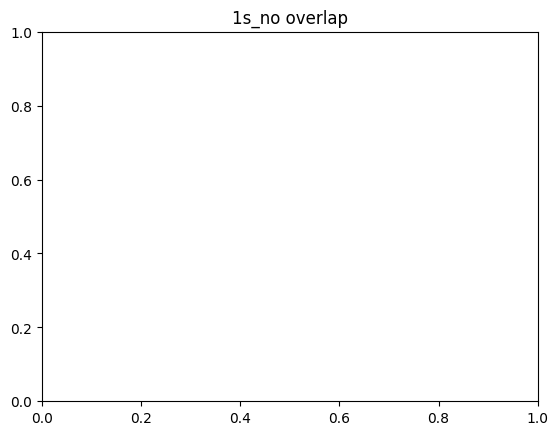

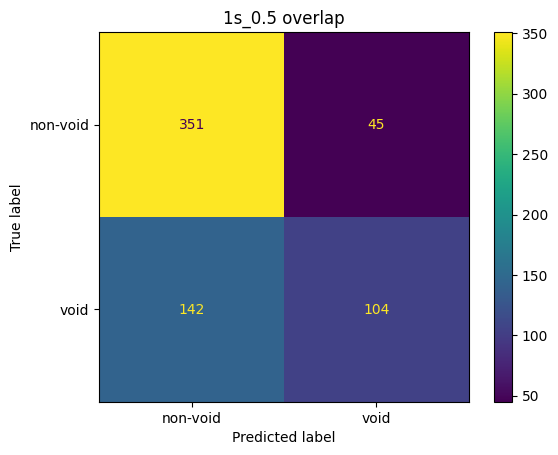

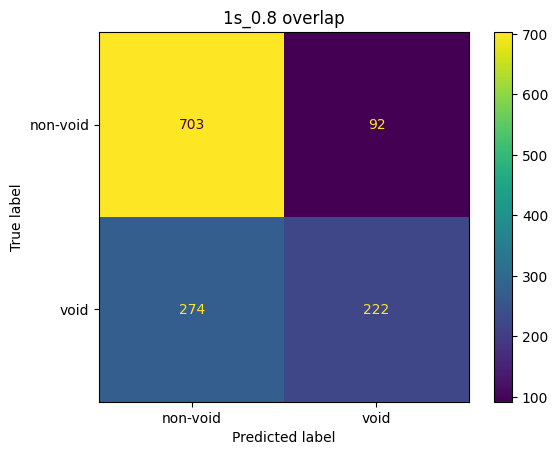

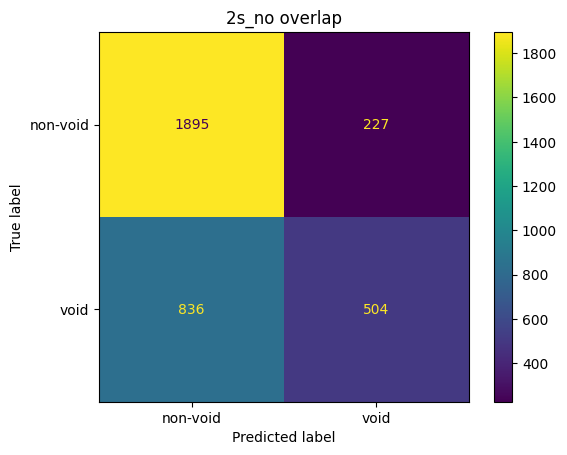

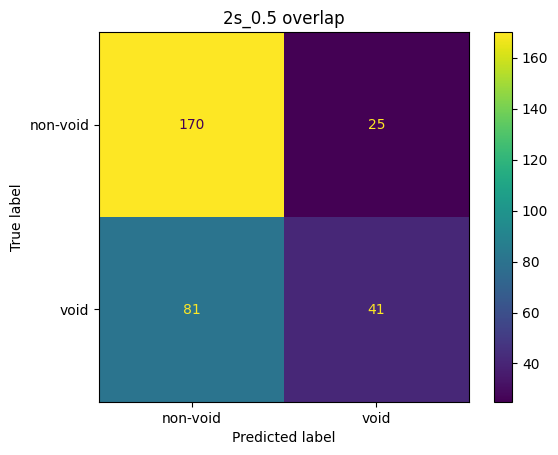

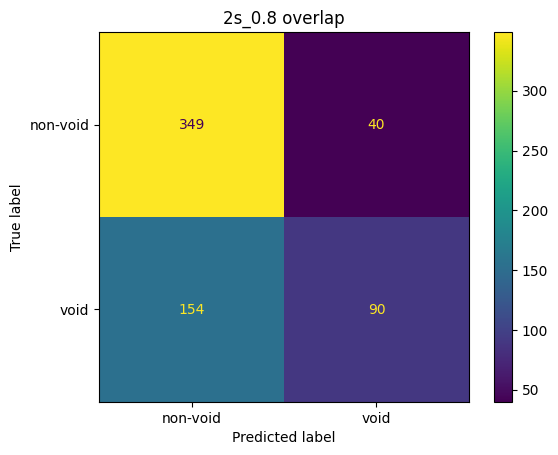

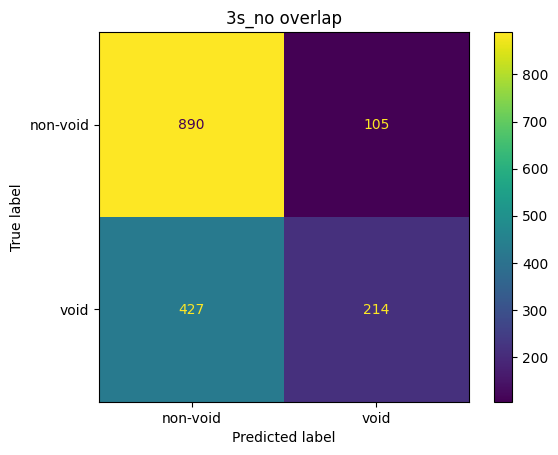

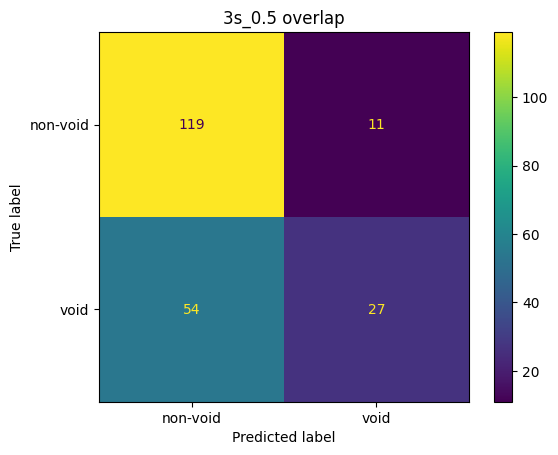

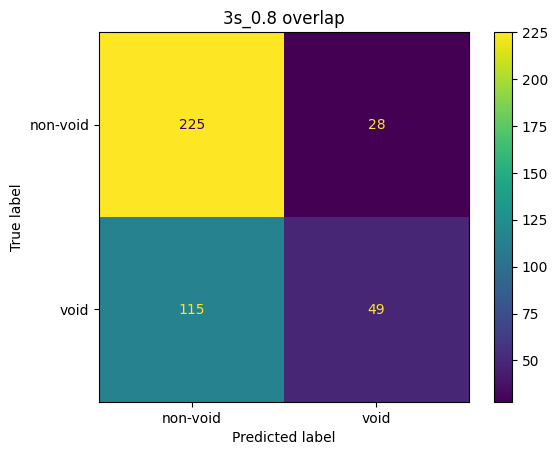

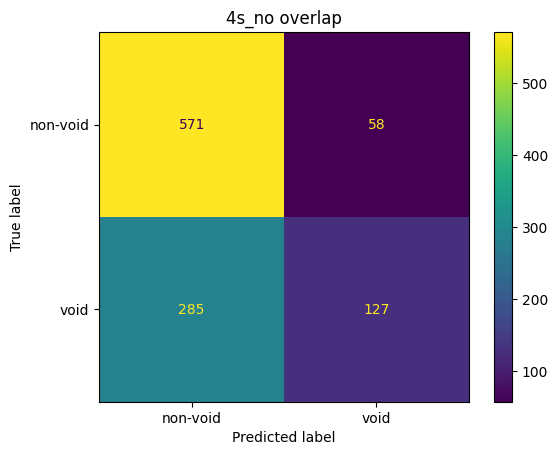

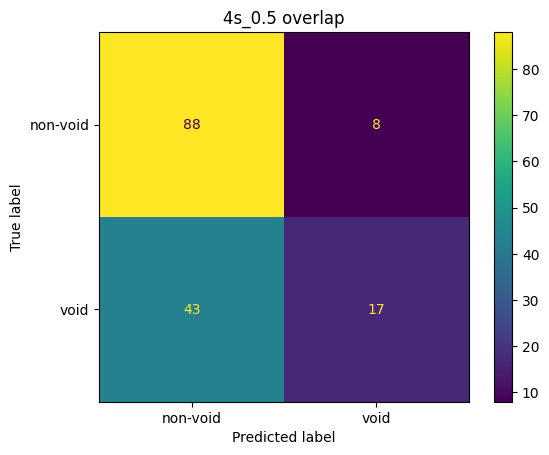

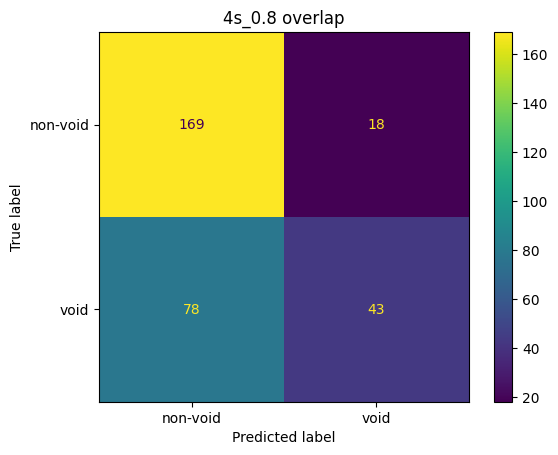

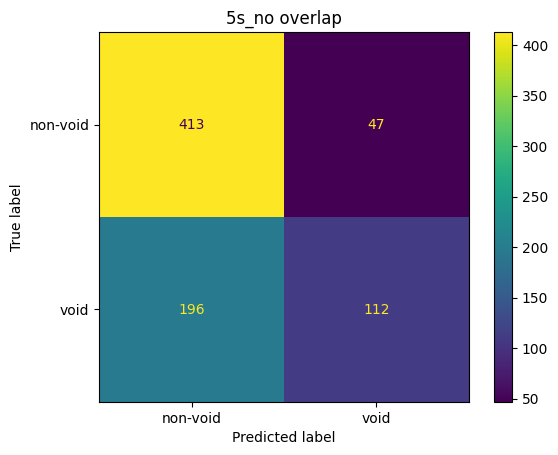

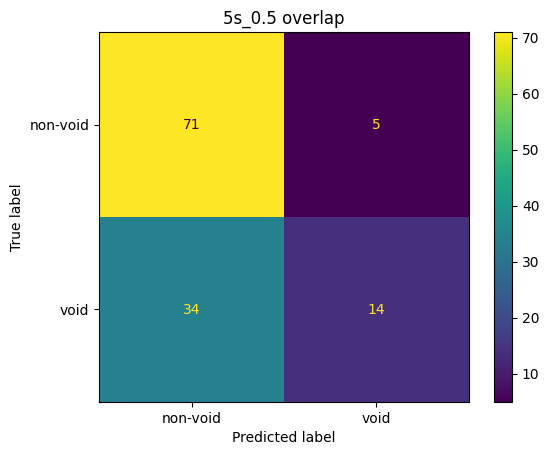

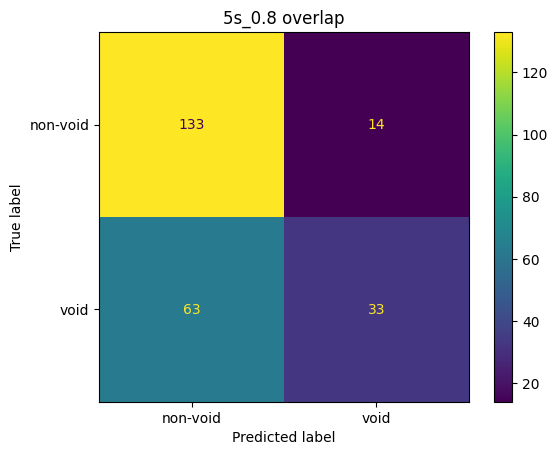

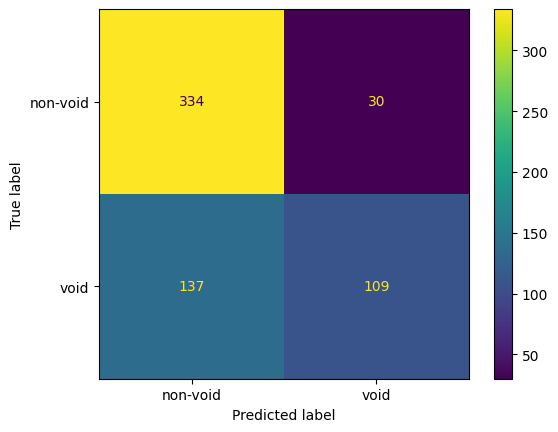

In [6]:
for file in files:
    data_path = os.path.join(base_path, file)
    features = pd.read_csv(data_path)
    features.drop(['center_time', 'start_time', 'end_time'], axis=1, inplace=True)
    details = file.split('_')
    exp_name = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    
    # Extracting the experiment_id from the filename
    details = file.split('_')
    win_overlap = f"{details[3]}_{details[-1].replace('.csv', '')}"
    
    # Split features and labels    
    X = features.drop(columns=['label', 'experiment_id'])
    y = features['label']
    groups = features['experiment_id']

    # Split the data into training and testing sets  
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(splitter.split(X, y, groups))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]
    
    # Encode labels
    label_encoder = LabelEncoder()
    # Encode y_test and y_train
    y_train_encoded = label_encoder.fit_transform(y_train) 
    y_test_encoded = label_encoder.transform(y_test)
    
    # Train the model
    xgb_model.fit(X_train, y_train_encoded)
    
    predictions = label_encoder.inverse_transform(xgb_model.predict(X_test))
    accuracy = accuracy_score(y_test, predictions)
    print("Accuracy: %.2f%%" % (accuracy * 100.0))
    
    report = classification_report(y_test, predictions)
    
    # save plots
    cm = confusion_matrix(y_test, predictions)
    cm_fig = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['non-void', 'void'])
    cm_fig_path = f"/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/model_plots/xgboost/default_params/cm_{exp_name}.png"
    plt.title(f'{exp_name} overlap')
    cm_fig.plot()
    plt.savefig(cm_fig_path)
    


    overlap = details[-1].replace('.csv', '')
    win_size = int(details[3].split('s')[0])
    overlap = float(overlap if overlap != 'no' else 0.0)

    
    params = xgb_model.get_params()
    params['window_size'] = win_size
    params['overlap'] = overlap
    params['exp_name'] = exp_name
    
    # Log the model
    log_experiment_run(
        model=xgb_model,
        X_test=X_test,
        report_dict=classification_report(y_test, predictions, output_dict=True),
        params=params,
        # experiment_name=f"RandomForest Default - {exp_name}",
        # model_name="RandomForest"
    )
    

In [7]:
# from hyperopt import fmin, tpe, hp, Trials

# params = {'random_state': 42}

# rounds = [{'max_depth': hp.quniform('max_depth', 1, 8, 1),
#         'min_child_weight': hp.loguniform('min_child_weight', -2, 3)},
#         {'subsample': hp.uniform('subsample', 0.5, 1.0),
#         'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0)},
#         {'reg_alpha': hp.loguniform('reg_alpha', 0, 10),
#         'reg_lambda': hp.loguniform('reg_lambda', 1, 10),},
#         {'gamma': hp.uniform('gamma', -10, 10)},
#         {'learning_rate': hp.uniform('learning_rate', -7, 0)}
#         ]

# all_trials = []
# for round in rounds:
#     params = {**params, **round}
#     trials = Trials()
#     best = fmin(fn=lambda space: hyperparameter_tuning(space, X_train, y_train_encoded,
#                                                 X_test, y_test_encoded),
#         space=params,
#         algo=tpe.suggest,
#         max_evals=50,
#         trials=trials,)
    
#     params = {**params, **best}
#     all_trials.append(trials)